In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("cleaned_churn.csv")

features = ["total_day_minutes", "total_eve_minutes",
            "total_night_minutes", "total_intl_minutes",
            "customer_service_calls", "account_length"]
X = df[features]
X.head()

,total_day_minutes,total_eve_minutes,total_night_minutes,total_intl_minutes,customer_service_calls,account_length
0,184.5,351.6,215.8,8.7,1,117
1,129.1,228.5,208.8,12.7,4,65
2,332.9,317.8,160.6,5.4,4,161
3,110.4,137.3,189.6,7.7,2,111
4,119.3,215.1,178.7,11.1,1,49


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

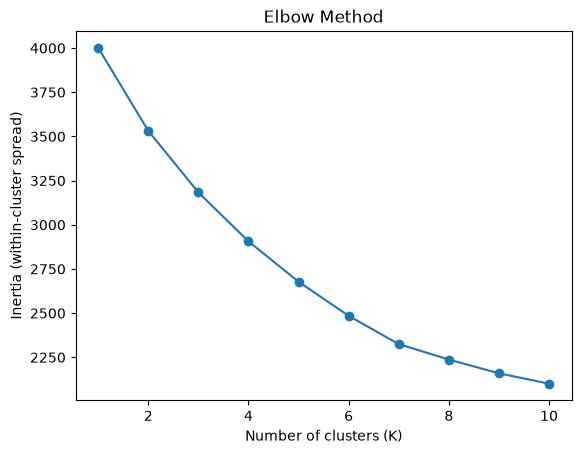

In [4]:
inertia = []
k_values = range(1, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (within-cluster spread)")
plt.title("Elbow Method")
plt.savefig("elbow.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

df["cluster"].value_counts()

cluster
2    283
1    202
0    182
Name: count, dtype: int64

In [6]:
df.groupby("cluster")[features + ["churn"]].mean().round(2)

,total_day_minutes,total_eve_minutes,total_night_minutes,total_intl_minutes,customer_service_calls,account_length,churn
cluster,,,,,,,
0,204.19,206.05,169.32,10.26,3.02,105.38,0.24
1,180.44,247.69,221.73,9.06,0.96,107.94,0.17
2,166.37,169.97,203.48,11.06,1.06,97.57,0.06


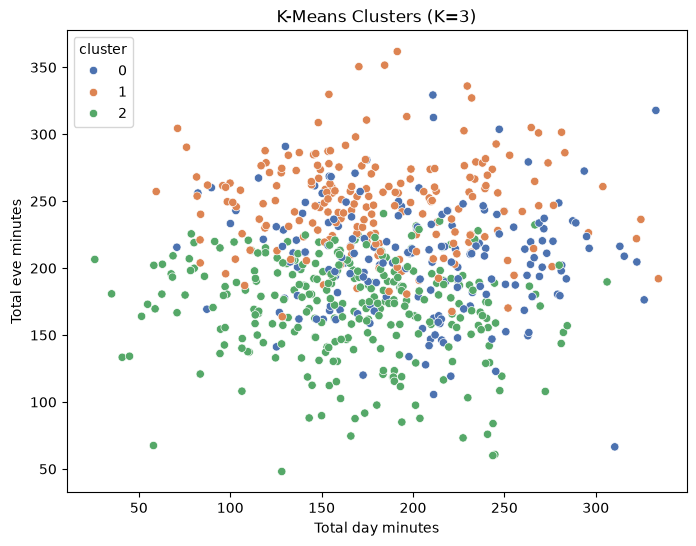

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="total_day_minutes", y="total_eve_minutes",
                hue="cluster", palette="deep", data=df)
plt.title("K-Means Clusters (K=3)")
plt.xlabel("Total day minutes")
plt.ylabel("Total eve minutes")
plt.savefig("clusters.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
print(df["cluster"].value_counts())
df.groupby("cluster")[features + ["churn"]].mean().round(2)

cluster
2    283
1    202
0    182
Name: count, dtype: int64


,total_day_minutes,total_eve_minutes,total_night_minutes,total_intl_minutes,customer_service_calls,account_length,churn
cluster,,,,,,,
0,204.19,206.05,169.32,10.26,3.02,105.38,0.24
1,180.44,247.69,221.73,9.06,0.96,107.94,0.17
2,166.37,169.97,203.48,11.06,1.06,97.57,0.06


Choice of K: The elbow plot showed no sharp bend, so I chose K = 3, where the steepest drop ends and the groups stay easy to interpret.

Clusters:

Cluster 0 (182 customers): high usage, frequent support callers. Highest day minutes and about 3 service calls on average. Highest churn rate (24%).
Cluster 1 (202 customers): evening and night heavy users. Churn rate 17%.
Cluster 2 (283 customers): light users. Lowest usage and about 1 service call. Lowest churn rate (6%).

The clusters overlap in the 2D plot because they were built from six features. Churn was not used to form the clusters, yet it varies strongly between them, suggesting that high usage combined with frequent support contact is a risk signal.